## Setup -- project path

Put repo root on **`sys.path`** so `app.*` imports work from this folder.


In [56]:
from pathlib import Path
import sys

_CWD = Path.cwd().resolve()
PROJECT_ROOT = _CWD.parent if _CWD.name == "notebooks" else _CWD
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT =", PROJECT_ROOT)


PROJECT_ROOT = C:\coding\boltech


## Load dataset

We load `claim_use_case_dataset.xlsx`, add surrogate `_pkey` (row number), and derive `approved` from `status` (Completed=1, Declined=0).


In [57]:
import numpy as np
import pandas as pd

data_path = PROJECT_ROOT / "claim_use_case_dataset.xlsx"
assert data_path.exists(), f"Missing {data_path}"

df = pd.read_excel(data_path, engine="openpyxl")
df.insert(0, "_pkey", np.arange(1, df.shape[0] + 1, dtype=np.int64))
#inserted own arbitrary pkey
df["approved"] = (df["status"].astype(str).str.strip().str.lower() == "completed").astype(int)
df.shape, df["approved"].mean().round(3)


((2880, 37), np.float64(0.843))

## EDA -- money columns: `excessFee`, `rrp`, `balanceRRP`, `oldBalanceRRP`, `deviceCost`

**Goal:** Summarize list price, balances, and excess; see how often **`rrp`** and **`balanceRRP`** differ (possible prior use of cover).

**Hypothesis:** None yet (descriptive only). We only shape columns for later tests.

**Procedure:** Coerce numerics, form **`rrp_minus_balance`** and **`fee_to_rrp`**.


In [58]:
money = ["excessFee", "rrp", "balanceRRP", "oldBalanceRRP", "deviceCost"]
for c in money:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["rrp_minus_balance"] = df["rrp"] - df["balanceRRP"]
df["fee_to_rrp"] = df["excessFee"] / df["rrp"].replace(0, np.nan)

print("same rrp/balance?", (df["rrp_minus_balance"].abs() < 0.01).mean().round(3))

df[["excessFee", "rrp", "balanceRRP", "oldBalanceRRP", "deviceCost"]].describe().T

# Interpretation:
# deviceCost is always 0 -- we use rrp as device value proxy.
# 93.7% of rows have rrp == balanceRRP, meaning most claims have no prior coverage erosion.
# excessFee ranges from 0 to 3629 with median 139 -- a tiered deductible schedule.


same rrp/balance? 0.937


,count,mean,std,min,25%,50%,75%,max
excessFee,2874.0,387.070633,446.548065,0.00,59.0,139.0,619.0,3629.0
rrp,2880.0,6926.282556,7300.148073,0.00,1349.0,1799.0,14490.0,43888.0
balanceRRP,2880.0,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
oldBalanceRRP,2880.0,6781.947028,7214.160287,-4861.33,1349.0,1799.0,13990.0,43888.0
deviceCost,2880.0,0.000000,0.000000,0.00,0.0,0.0,0.0,0.0


## Check -- rows where `rrp` and `balanceRRP` diverge

**Goal:** List claims with **non-trivial** **RRP − balance** (here **≥ 0.01**).

**Hypothesis:** Not a formal test; we only quantify how many rows show erosion of **balanceRRP** versus list **rrp** (same-row snapshot only; not a device time series).


In [59]:
sub = df[df["rrp_minus_balance"].abs() >= 0.01].copy()
len(sub), sub.head(6)[["excessFee", "rrp", "balanceRRP", "rrp_minus_balance", "status"]]

# Interpretation:
# 182 rows (~6.3%) show rrp != balanceRRP. These may be repeat claims or
# partial coverage consumption. Without a device ID, we cannot track this longitudinally.


(182,
      excessFee      rrp  balanceRRP  rrp_minus_balance     status
 85       619.0  13490.0    10932.00            2558.00  Completed
 145      369.0   2990.0     1625.48            1364.52  Completed
 152      619.0  14490.0    11448.28            3041.72  Completed
 165      619.0  17790.0    15252.13            2537.87  Completed
 179     1039.0  13490.0        0.00           13490.00  Completed
 184      619.0  14490.0    11416.60            3073.40  Completed)

## Test -- Pearson r: fee columns vs `approved`

We compute Pearson correlation between each money field and `approved` to screen for linear association.

**Caveat:** Small |r| against a 0/1 outcome does not rule out non-linear structure. Use chi-square on bins/categories for a better test.


In [60]:
cols = ["excessFee", "rrp", "balanceRRP", "oldBalanceRRP", "deviceCost", "rrp_minus_balance"]

_money_corr = pd.Series({c: df[c].corr(df["approved"]) for c in cols}).sort_values(key=abs, ascending=False)
_money_corr

# Interpretation:
# All |r| values are below 0.07, indicating very weak linear correlation with approval.
# deviceCost is NaN because it has zero variance (all zeros).
# Weak Pearson r does NOT mean no relationship -- it means no strong *linear* one.
# We use chi-square on binned/categorical versions below for a better test.


c:\Users\seant\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\seant\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


rrp                  0.067521
oldBalanceRRP        0.065311
balanceRRP           0.065311
rrp_minus_balance    0.024403
excessFee           -0.012427
deviceCost                NaN
dtype: float64

## Policy span -- derived date fields

We parse `policyStartDate`, `policyEndDate`, `purchaseDate` and derive `coverage_duration_days`, `purchase_to_policy_end_days`, and `coverage_duration_tier` (6m / 12m / 24m bands). Tier can also be inferred from `productName`.

**Note:** There is no claim/send-in date, so "days to expiry at claim time" cannot be computed.


In [61]:
# policy span -- derived fields, marginals, correlations, tier table
_ps = pd.to_datetime(df["policyStartDate"], errors="coerce", dayfirst=True)
_pe = pd.to_datetime(df["policyEndDate"], errors="coerce", dayfirst=True)
_pu = pd.to_datetime(df["purchaseDate"], errors="coerce", dayfirst=True)

df["coverage_duration_days"] = (_pe - _ps).dt.days.astype(float)
df["purchase_to_policy_end_days"] = (_pe - _pu).dt.days.astype(float)

_both = _ps.notna() & _pu.notna() & _pe.notna()
df["days_after_policy_anchor_to_end"] = np.nan
df.loc[_both, "days_after_policy_anchor_to_end"] = (
    _pe[_both] - pd.concat([_ps[_both], _pu[_both]], axis=1).max(axis=1)
).dt.days.astype(float)


def coverage_duration_tier(d: object) -> object:
    if d is None or (isinstance(d, float) and not np.isfinite(d)):
        return pd.NA
    d = float(d)
    if d < 120:
        return "outlier_lt120d"
    if d <= 275:
        return "tier_appx_6mo"
    if d <= 550:
        return "tier_appx_12mo"
    return "tier_appx_24mo"


df["coverage_duration_tier"] = df["coverage_duration_days"].map(coverage_duration_tier).astype("string")

print("Top exact policy-span day values (ties drive qcut behaviour)")
print(df["coverage_duration_days"].value_counts().head(20))

print("\ncoverage duration (days) - describe")
print(df["coverage_duration_days"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())
print("\npurchase to policy end (days)")
print(df["purchase_to_policy_end_days"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())
print("\nmax(policyStart,purchase) to policy end (days)")
print(df["days_after_policy_anchor_to_end"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())

_time_cols = [
    "coverage_duration_days",
    "purchase_to_policy_end_days",
    "days_after_policy_anchor_to_end",
]
print("\nfraction valid:\n", df[_time_cols].notna().mean().round(3).to_string())

pear = pd.Series({c: df[c].corr(df["approved"], method="pearson") for c in _time_cols})
spear = pd.Series({c: df[c].corr(df["approved"], method="spearman") for c in _time_cols})

print("\nPearson / Spearman vs approved (completed=1)")
pd.concat([pear.rename("pearson"), spear.rename("spearman")], axis=1)

tier_order = ["outlier_lt120d", "tier_appx_6mo", "tier_appx_12mo", "tier_appx_24mo"]
tier_tbl = (
    df.dropna(subset=["coverage_duration_tier"])
    .assign(
        coverage_duration_tier=lambda x: pd.Categorical(
            x["coverage_duration_tier"], categories=tier_order, ordered=True
        )
    )
    .groupby("coverage_duration_tier", observed=False)["approved"]
    .agg(approved_n="sum", n="count", approve_rate="mean")
    .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
)
print("\n--- Approval by SKU-style coverage tier (preferred over quantile bins)")
tier_tbl

# Interpretation:
# Pearson/Spearman correlations with approved are very weak (|r| < 0.07).
# This is expected: day counts are discrete SKU lengths, not a continuous predictor.
# The tier table shows most claims are 12-month policies (~71%), with approval ~83-90% across tiers.


Top exact policy-span day values (ties drive qcut behaviour)
coverage_duration_days
365.0    1146
366.0     838
731.0     435
730.0     149
6.0        87
181.0      73
359.0      43
184.0      42
360.0      25
183.0      22
182.0      20
Name: count, dtype: int64

coverage duration (days) - describe
count    2880.000000
mean      418.513542
std       173.170532
min         6.000000
5%        181.000000
25%       365.000000
50%       365.000000
75%       366.000000
95%       731.000000
max       731.000000

purchase to policy end (days)
count    2880.000000
mean      431.357292
std       183.703931
min         6.000000
5%        181.000000
25%       365.000000
50%       366.000000
75%       451.000000
95%       731.000000
max       913.000000

max(policyStart,purchase) to policy end (days)
count    2880.000000
mean      415.781597
std       173.708069
min         6.000000
5%        181.000000
25%       365.000000
50%       365.000000
75%       366.000000
95%       731.000000
max       7

,approved_n,n,approve_rate,declined_n,deny_rate
coverage_duration_tier,,,,,
outlier_lt120d,72,87,0.827586,15,0.172414
tier_appx_6mo,142,157,0.904459,15,0.095541
tier_appx_12mo,1701,2052,0.828947,351,0.171053
tier_appx_24mo,512,584,0.876712,72,0.123288


## Note -- `qcut` vs discrete SKU lengths

Coverage durations cluster on discrete values (365, 366, 730, 731 days). Equal-count `qcut` bins split these clusters arbitrarily, so we analyze exact day counts and product tiers first.


## Sanity check -- does `purchaseDate` clip the coverage window?

We check whether the handset was purchased before, during, or after the policy period. If `purchaseDate` falls outside `[policyStartDate, policyEndDate]`, it means the coverage window is not anchored to the sale -- the product was sold separately from when coverage began or ended.


In [62]:
# Where does purchaseDate sit relative to the policy window?
_pu_check = df[["_pkey"]].copy()
_pu_check["purchaseDate"] = _pu
_pu_check["policyStart"] = _ps
_pu_check["policyEnd"] = _pe

# Classify each row
_valid = _pu.notna() & _ps.notna() & _pe.notna()
_pu_check["purchase_position"] = pd.NA
_pu_check.loc[_valid & (_pu < _ps), "purchase_position"] = "before_coverage"  # bought before policy starts
_pu_check.loc[_valid & (_pu >= _ps) & (_pu <= _pe), "purchase_position"] = "during_coverage"  # bought while policy active
_pu_check.loc[_valid & (_pu > _pe), "purchase_position"] = "after_coverage"   # bought AFTER policy ended (anomaly)

print("=== Purchase date vs coverage window ===")
print(_pu_check["purchase_position"].value_counts(dropna=False).to_string())
print()

# How many days before/after policy start?
_pu_check["days_purchase_before_start"] = (_ps - _pu).dt.days  # positive = bought before start
_pu_check["days_purchase_after_end"] = (_pu - _pe).dt.days     # positive = bought after end (bad)

print("--- Rows where purchase is BEFORE policy start (bought early) ---")
_before = _pu_check[_pu_check["purchase_position"] == "before_coverage"]
print(f"  count: {len(_before)}")
if len(_before) > 0:
    print(f"  days_purchase_before_start: mean={_before['days_purchase_before_start'].mean():.1f}, "
          f"median={_before['days_purchase_before_start'].median():.0f}, "
          f"max={_before['days_purchase_before_start'].max():.0f}")
print()

print("--- Rows where purchase is DURING coverage (normal) ---")
_during = _pu_check[_pu_check["purchase_position"] == "during_coverage"]
print(f"  count: {len(_during)}")
print()

print("--- Rows where purchase is AFTER policy end (anomaly) ---")
_after = _pu_check[_pu_check["purchase_position"] == "after_coverage"]
print(f"  count: {len(_after)}")
if len(_after) > 0:
    print(f"  days_purchase_after_end: mean={_after['days_purchase_after_end'].mean():.1f}")
    print(_after[["_pkey", "purchaseDate", "policyStart", "policyEnd", "days_purchase_after_end"]].head(10).to_string())
print()

# Does purchase position affect whether coverage_duration_days == purchase_to_policy_end_days?
print("--- Coverage duration vs purchase-to-end gap ---")
_pu_check["cov_dur"] = df["coverage_duration_days"]
_pu_check["pur_to_end"] = df["purchase_to_policy_end_days"]
_pu_check["delta"] = _pu_check["pur_to_end"] - _pu_check["cov_dur"]
print("  delta (purchase_to_end - coverage_duration) describe:")
print(_pu_check["delta"].describe().to_string())
print(f"\n  Rows where delta != 0: {(_pu_check['delta'].abs() > 0.5).sum()}")
print(f"  Rows where delta == 0: {(_pu_check['delta'].abs() <= 0.5).sum()}")

# Interpretation:
# If most rows have purchase DURING coverage and delta ~ 0, then purchaseDate ~ policyStartDate
# and purchase_to_policy_end_days ~ coverage_duration_days (redundant).
# If many rows have purchase BEFORE coverage, the device was bought before the policy kicked in,
# meaning purchase_to_end > coverage_duration -- purchase date does NOT clip coverage.
# If any rows have purchase AFTER policy end, those are data quality issues.


=== Purchase date vs coverage window ===
purchase_position
during_coverage    2615
before_coverage     265

--- Rows where purchase is BEFORE policy start (bought early) ---
  count: 265
  days_purchase_before_start: mean=169.3, median=87, max=366

--- Rows where purchase is DURING coverage (normal) ---
  count: 2615

--- Rows where purchase is AFTER policy end (anomaly) ---
  count: 0

--- Coverage duration vs purchase-to-end gap ---
  delta (purchase_to_end - coverage_duration) describe:
count    2880.000000
mean       12.843750
std        72.614365
min      -260.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       366.000000

  Rows where delta != 0: 594
  Rows where delta == 0: 2286


## Test -- exact coverage days vs `approved`

We run Pearson chi-square on the full contingency table of exact `coverage_duration_days` x `approved` to test if approval rate depends on the specific policy length.

**H0:** Approval is independent of exact day count. **H1:** There is an association.



--- Discrete coverage_duration_days: every distinct span (sorted by row count) ---
unique day values: 11
                        approved_n     n  approve_rate  declined_n  deny_rate
coverage_duration_days                                                       
365.0                          943  1146      0.822862         203   0.177138
366.0                          700   838      0.835322         138   0.164678
731.0                          382   435      0.878161          53   0.121839
730.0                          130   149      0.872483          19   0.127517
6.0                             72    87      0.827586          15   0.172414
181.0                           67    73      0.917808           6   0.082192
359.0                           37    43      0.860465           6   0.139535
184.0                           39    42      0.928571           3   0.071429
360.0                           21    25      0.840000           4   0.160000
183.0                           18  

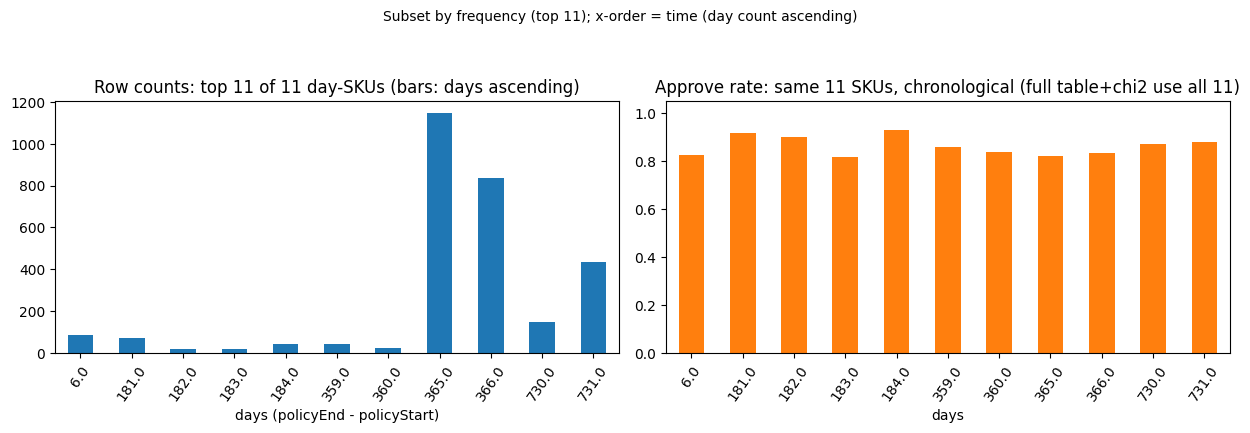

In [63]:
# exact calendar-day SKUs -- table, chi-square, top-K plots
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

_cd_finite = df["coverage_duration_days"].notna() & np.isfinite(df["coverage_duration_days"])
_cd_tbl = (
    df.loc[_cd_finite]
    .groupby("coverage_duration_days", observed=False)["approved"]
    .agg(approved_n="sum", n="count", approve_rate="mean")
    .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    .sort_values("n", ascending=False)
)
print("\n--- Discrete coverage_duration_days: every distinct span (sorted by row count) ---")
print("unique day values:", int(df.loc[_cd_finite, "coverage_duration_days"].nunique()))
print(_cd_tbl.to_string())

_cd_ct = pd.crosstab(
    df.loc[_cd_finite, "coverage_duration_days"].astype(str),
    df.loc[_cd_finite, "approved"],
)
_chi2_cd, _p_cd, _dof_cd, _exp_cd = chi2_contingency(_cd_ct)
_n_cd = int(_cd_ct.values.sum())
_dfm_cd = max(min(_cd_ct.shape[0] - 1, _cd_ct.shape[1] - 1), 1)
_v_cd = float(np.sqrt(_chi2_cd / (_n_cd * _dfm_cd))) if _n_cd else float("nan")
print(
    f"exact_day_chi2: df={_dof_cd:.0f} chi2={_chi2_cd:.4f} p={_p_cd:.4g} CramerV={_v_cd:.4f} min_exp={float(_exp_cd.min()):.2f}"
)

_cd_n_nominal = int(_cd_tbl.shape[0])
_cd_plot_k = min(25, _cd_n_nominal)
_cd_top = _cd_tbl.head(_cd_plot_k).sort_index()
fig_cd, ax_cd = plt.subplots(1, 2, figsize=(12.5, 4.2))
_cd_top["n"].plot(kind="bar", ax=ax_cd[0], rot=55, legend=False, color="C0")
ax_cd[0].set_title(
    f"Row counts: top {_cd_plot_k} of {_cd_n_nominal} day-SKUs (bars: days ascending)"
)
ax_cd[0].set_xlabel("days (policyEnd - policyStart)")

_cd_top["approve_rate"].astype(float).plot(kind="bar", ax=ax_cd[1], rot=55, legend=False, color="C1")
ax_cd[1].set_ylim(0, 1.05)
ax_cd[1].set_title(
    f"Approve rate: same {_cd_plot_k} SKUs, chronological (full table+chi2 use all {_cd_n_nominal})",
)
ax_cd[1].set_xlabel("days")
fig_cd.suptitle(
    f"Subset by frequency (top {_cd_plot_k}); x-order = time (day count ascending)",
    fontsize=10,
    y=1.02,
)
plt.tight_layout(rect=(0, 0, 1, 0.96))

# Interpretation:
# p ~ 0.126 > 0.05, so we fail to reject H0.
# Approval rate does not significantly depend on the exact calendar-day policy length.
# However, min_exp is 3.15 (below 5), which weakens the asymptotic chi-square approximation.


## Test -- coverage tier (6m / 12m / 24m) vs `approved`

We run chi-square on `coverage_duration_tier` x `approved` to test if the coarser product tier affects approval.

**H0:** Tier is independent of approval. **H1:** There is an association.


tier_chi2: df=3 chi2=12.6924 p=0.005351 CramerV=0.0664 min_exp=13.68


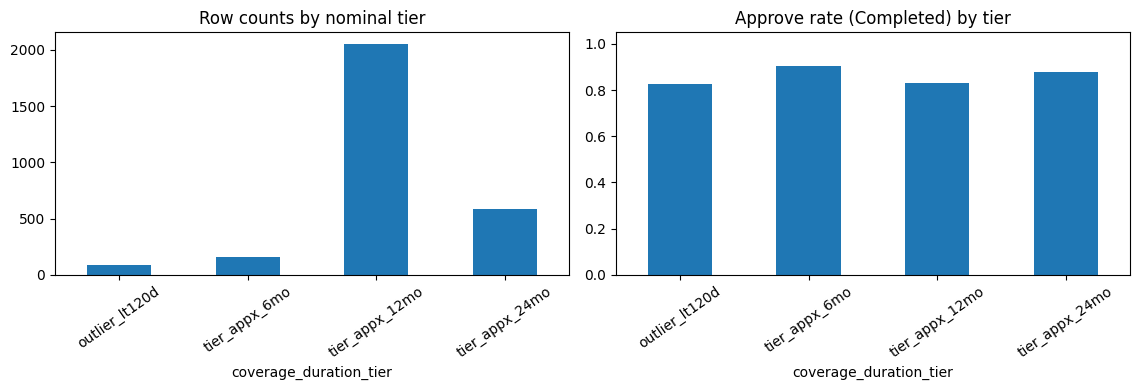

In [64]:
# nominal tier -- chi-square + bar charts (uses tier_order from prior cell)
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

_tier_ct = pd.crosstab(df["coverage_duration_tier"].fillna("<missing>").astype(str), df["approved"])
_chi2_t, _p_t, _dof_t, _exp_t = chi2_contingency(_tier_ct)
_n_t = int(_tier_ct.values.sum())
_dfm_t = max(min(_tier_ct.shape[0] - 1, _tier_ct.shape[1] - 1), 1)
_v_t = float(np.sqrt(_chi2_t / (_n_t * _dfm_t))) if _n_t else float("nan")
print(
    f"tier_chi2: df={_dof_t:.0f} chi2={_chi2_t:.4f} p={_p_t:.4g} CramerV={_v_t:.4f} min_exp={float(_exp_t.min()):.2f}"
)

_ord = tier_order
_cnt = df.groupby("coverage_duration_tier", observed=False).size().reindex(_ord)
_rate = df.groupby("coverage_duration_tier", observed=False)["approved"].mean().reindex(_ord)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
_cnt.fillna(0).plot(kind="bar", ax=axes[0], rot=35, legend=False)
axes[0].set_title("Row counts by nominal tier")
axes[0].set_xlabel("coverage_duration_tier")

_rate.astype(float).plot(kind="bar", ax=axes[1], rot=35, legend=False)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Approve rate (Completed) by tier")
axes[1].set_xlabel("coverage_duration_tier")
plt.tight_layout()

# Interpretation:
# p ~ 0.005 < 0.05, so we reject H0. There IS a significant association between
# coverage tier and approval. Cramer's V ~ 0.066 indicates a weak but real effect.
# The 6-month tier has the highest approval (~90%), the 12-month tier the lowest (~83%).


## Exploratory -- `qcut` bins on day columns

Equal-count quintile bins. This is exploratory only -- bins don't respect product SKU boundaries.


In [65]:
# qcut quintiles -- exploratory only
for tc in _time_cols:
    sub = df[["approved", tc]].copy()
    sub[tc] = pd.to_numeric(sub[tc], errors="coerce")
    sub = sub.loc[sub[tc].notna() & np.isfinite(sub[tc])]
    vv = sub[tc]
    if len(vv) < 40:
        print(f"\n--- {tc}: skip quintiles (n={len(vv)}) ---")
        continue
    qb = pd.qcut(vv, q=5, duplicates="drop")
    tbl = (
        sub.assign(_qbin=qb)
        .groupby("_qbin", observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    )
    print(f"\n--- {tc} - pd.qcut q=5, duplicates=dropped (EDA only) ---")
    print(tbl.to_string())

# Interpretation:
# qcut bins collapse due to massive ties at 365/366/730. Resulting bins span
# non-uniform ranges. Use the exact-day and tier tables above for decisions.



--- coverage_duration_days - pd.qcut q=5, duplicates=dropped (EDA only) ---
                approved_n     n  approve_rate  declined_n  deny_rate
_qbin                                                                
(5.999, 365.0]        1215  1458      0.833333         243   0.166667
(365.0, 366.0]         700   838      0.835322         138   0.164678
(366.0, 730.0]         130   149      0.872483          19   0.127517
(730.0, 731.0]         382   435      0.878161          53   0.121839

--- purchase_to_policy_end_days - pd.qcut q=5, duplicates=dropped (EDA only) ---
                approved_n     n  approve_rate  declined_n  deny_rate
_qbin                                                                
(5.999, 365.0]        1087  1307      0.831676         220   0.168324
(365.0, 366.0]         675   811      0.832306         136   0.167694
(366.0, 730.0]         220   254      0.866142          34   0.133858
(730.0, 913.0]         445   508      0.875984          63   0.124016



## Test -- `rrp` (device list price) vs `approved`

We check if the device list price is associated with approval. If there are <= 25 distinct positive prices, we treat `rrp` as categorical. Otherwise we use `qcut(q=5)` to create equal-frequency bins.

**H0:** `rrp` level/bin is independent of approval. **H1:** There is an association.


In [66]:
# rrp: few distinct list prices -> categorical; many -> qcut bands
rrp_num = pd.to_numeric(df["rrp"], errors="coerce")
mask = rrp_num.notna() & (rrp_num > 0)
_rrp_vals = rrp_num[mask]
_rrp_nu = int(_rrp_vals.nunique())
print("rrp distinct positive values:", _rrp_nu)

from scipy.stats import chi2_contingency

if _rrp_nu <= 25:
    rrp_sub = df.loc[mask, ["approved"]].copy()
    rrp_sub["rrp_level"] = _rrp_vals.values
    rrp_table = (
        rrp_sub.groupby("rrp_level", observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(
            declined_n=lambda t: t["n"] - t["approved_n"],
            deny_rate=lambda t: 1.0 - t["approve_rate"],
        )
        .sort_values("n", ascending=False)
    )
    _rrp_ct = pd.crosstab(rrp_sub["rrp_level"], rrp_sub["approved"])
    _mode = "exact_rrp_levels"
else:
    rrp_sub = df.loc[mask, ["approved"]].copy()
    rrp_sub["rrp_qbin"] = pd.qcut(rrp_num[mask], q=5, duplicates="drop")
    rrp_table = (
        rrp_sub.groupby("rrp_qbin", observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(
            declined_n=lambda t: t["n"] - t["approved_n"],
            deny_rate=lambda t: 1.0 - t["approve_rate"],
        )
    )
    _rrp_ct = pd.crosstab(rrp_sub["rrp_qbin"], rrp_sub["approved"])
    _mode = "rrp_qcut_q5"

_rrp_chi2, _rrp_p, _rrp_dof, _rrp_exp = chi2_contingency(_rrp_ct)
_rrp_n = int(_rrp_ct.values.sum())
_rrp_dfm = max(min(_rrp_ct.shape[0] - 1, _rrp_ct.shape[1] - 1), 1)
_rrp_v = float(np.sqrt(_rrp_chi2 / (_rrp_n * _rrp_dfm))) if _rrp_n else float("nan")
print(
    f"{_mode}_chi2: df={_rrp_dof:.0f} chi2={_rrp_chi2:.4f} p={_rrp_p:.4g} CramerV={_rrp_v:.4f} min_exp={float(_rrp_exp.min()):.2f}"
)

rrp_table

# Interpretation:
# 187 distinct positive rrp values -> qcut used.
# p ~ 5.65e-09 << 0.05, so we reject H0. Device list-price bin IS significantly
# associated with approval. Cramer's V ~ 0.124 indicates a moderate effect.
# The lowest price band (49-1319 SEK) has the lowest approval rate (~77%).


rrp distinct positive values: 187
rrp_qcut_q5_chi2: df=4 chi2=44.2658 p=5.65e-09 CramerV=0.1240 min_exp=60.82


,approved_n,n,approve_rate,declined_n,deny_rate
rrp_qbin,,,,,
"(48.999, 1319.0]",504,655,0.769466,151,0.230534
"(1319.0, 1579.0]",603,685,0.880292,82,0.119708
"(1579.0, 2990.0]",316,388,0.814433,72,0.185567
"(2990.0, 15490.0]",584,667,0.875562,83,0.124438
"(15490.0, 43888.0]",419,482,0.869295,63,0.130705


## EDA -- excess fee relative to device price

We check if the proportion of repair cost (excess fee) to the device value (`excessFee / rrp`) affects approval rate. `excessFee` appears to be a numerically categorical schedule -- we also show its top tiers.

The 3-panel chart below shows mean excess fee, mean RRP, and deny rate across ratio bins.


excess/rrp distinct finite values: 347


,approved_n,n,approve_rate,declined_n,deny_rate
ratio_qbin,,,,,
"(-0.001, 0.0374]",642,730,0.879452,88,0.120548
"(0.0374, 0.0422]",393,431,0.911833,38,0.088167
"(0.0422, 0.0585]",494,574,0.860627,80,0.139373
"(0.0585, 0.0983]",461,571,0.807356,110,0.192644
"(0.0983, 1.843]",435,565,0.769912,130,0.230088


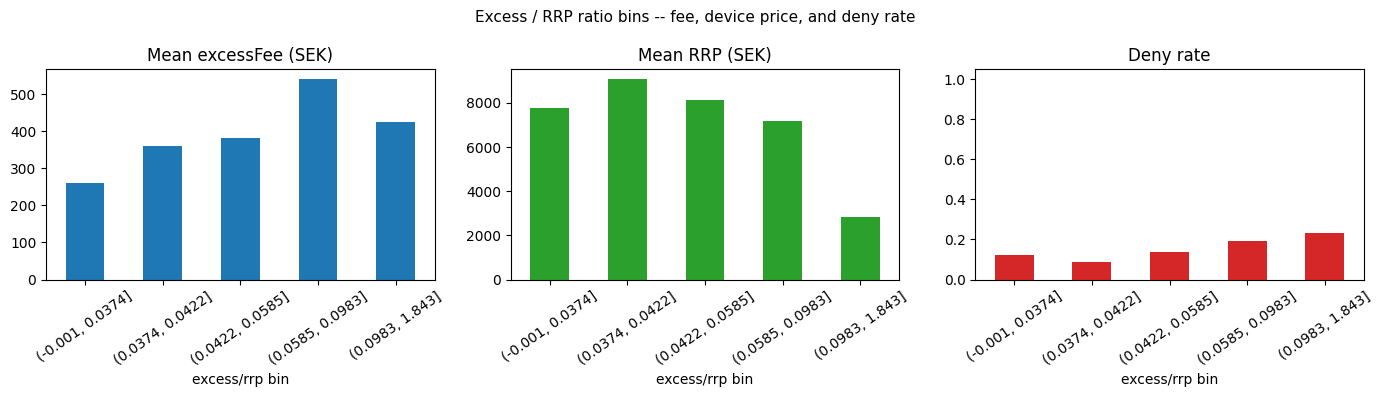

excessFee n_unique: 40


,approved_n,n,approve_rate,declined_n,deny_rate
excessFee_num,,,,,
35.0,42,65,0.646154,23,0.353846
59.0,837,967,0.865564,130,0.134436
99.0,40,43,0.930233,3,0.069767
109.0,61,74,0.824324,13,0.175676
139.0,248,320,0.775000,72,0.225000
199.0,78,107,0.728972,29,0.271028
589.0,168,189,0.888889,21,0.111111
619.0,578,642,0.900312,64,0.099688
1039.0,26,36,0.722222,10,0.277778


In [67]:
# excess / rrp ratio (qcut if many distinct values) + categorical excessFee tiers
import matplotlib.pyplot as plt
from IPython.display import display

_exc = df.assign(
    excess_ratio=lambda d: pd.to_numeric(d["excessFee"], errors="coerce")
    / pd.to_numeric(d["rrp"], errors="coerce").replace({0: np.nan}),
).dropna(subset=["excess_ratio"])

_tmp_er = _exc[np.isfinite(_exc["excess_ratio"])].copy()
_nu_ratio = int(_tmp_er["excess_ratio"].nunique())
print("excess/rrp distinct finite values:", _nu_ratio)

if _nu_ratio <= 12:
    exc_ratio_tbl = (
        _tmp_er.assign(ratio_bucket=_tmp_er["excess_ratio"].round(6))
        .groupby("ratio_bucket", observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    )
else:
    _tmp_er["ratio_qbin"] = pd.qcut(_tmp_er["excess_ratio"], q=5, duplicates="drop")
    exc_ratio_tbl = (
        _tmp_er.groupby("ratio_qbin", observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    )

display(exc_ratio_tbl)

# --- 3-panel visualization: mean excess, mean RRP, deny rate by ratio bin ---
_er_agg = (
    _tmp_er.assign(
        _bin=pd.qcut(_tmp_er["excess_ratio"], q=5, duplicates="drop").astype(str)
    )
    .groupby("_bin", observed=True)
    .agg(n=("approved", "count"), mean_excess_sek=("excessFee", "mean"), mean_rrp_sek=("rrp", "mean"), deny_rate=("approved", lambda x: 1.0 - x.mean()))
    .sort_index()
)

fig_er, ax_er = plt.subplots(1, 3, figsize=(14, 4))
fig_er.suptitle("Excess / RRP ratio bins -- fee, device price, and deny rate", fontsize=11)

_er_agg["mean_excess_sek"].plot(kind="bar", ax=ax_er[0], rot=35, color="C0")
ax_er[0].set_title("Mean excessFee (SEK)")
ax_er[0].set_xlabel("excess/rrp bin")

_er_agg["mean_rrp_sek"].plot(kind="bar", ax=ax_er[1], rot=35, color="C2")
ax_er[1].set_title("Mean RRP (SEK)")
ax_er[1].set_xlabel("excess/rrp bin")

_er_agg["deny_rate"].plot(kind="bar", ax=ax_er[2], rot=35, color="C3")
ax_er[2].set_title("Deny rate")
ax_er[2].set_ylim(0, 1.05)
ax_er[2].set_xlabel("excess/rrp bin")

plt.tight_layout()
plt.show()

# --- Categorical excessFee tiers ---
_ef = pd.to_numeric(df["excessFee"], errors="coerce")
print("excessFee n_unique:", int(_ef.dropna().nunique()))

_ef_top = _ef.value_counts().head(12).index
_sub = df.loc[_ef.isin(_ef_top)].copy()
_sub["excessFee_num"] = pd.to_numeric(_sub["excessFee"], errors="coerce")
_sub.groupby("excessFee_num", observed=False)["approved"].agg(
    approved_n="sum",
    n="count",
    approve_rate="mean",
).assign(
    declined_n=lambda t: t["n"] - t["approved_n"],
    deny_rate=lambda t: 1.0 - t["approve_rate"],
)

# Interpretation:
# Higher excess/rrp ratios generally correspond to lower deny rates.
# Categorical excessFee tiers show notable variation: fee=35 has ~64% approval
# while fee=619 has ~90%. This suggests excess fee level is predictive.


## Helper functions -- chi-square, pairwise z-tests, Holm correction

Reusable functions for the categorical association tests below.


In [68]:
from scipy.stats import chi2_contingency, norm
from IPython.display import display


def outcome_by_category(dd: pd.DataFrame, col: str) -> pd.DataFrame:
    out = (
        dd.groupby(col, dropna=False, observed=True)["approved"]
        .agg(approved_n="sum", n="count", approve_rate="mean")
        .assign(
            declined_n=lambda t: t["n"] - t["approved_n"],
            deny_rate=lambda t: 1.0 - t["approve_rate"],
        )
        .sort_values("n", ascending=False)
    )
    return out


def chi_square_report(dd: pd.DataFrame, col: str, label: str) -> None:
    ct = pd.crosstab(dd[col].fillna("<missing>"), dd["approved"])
    chi2, p, dof, exp = chi2_contingency(ct)
    n = int(ct.values.sum())
    r, k = ct.shape
    dfm = max(min(r - 1, k - 1), 1)
    v = float(np.sqrt(chi2 / (n * dfm))) if n else float("nan")
    print(
        f"{label}_chi2: df={dof:g} chi2={chi2:.3f} p={p:.4g} CramerV={v:.4f} min_exp={float(exp.min()):.2f}",
    )


def holm_adjust(pvals: np.ndarray) -> np.ndarray:
    """Holm-Bonferroni adjusted p-values (returns same order as input)."""
    x = np.asarray(pvals, dtype=float)
    m = len(x)
    if m <= 1:
        return np.minimum(x, 1.0)
    order = np.argsort(x)
    sp = x[order]
    adj = sp * (m - np.arange(m))
    for i in range(m - 2, -1, -1):
        adj[i] = max(adj[i], adj[i + 1])
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out


def pairwise_proportions(dd: pd.DataFrame, col: str, *, min_n: int = 5) -> pd.DataFrame:
    """Two-proportion z-test for each unordered category pair. Holm-adjust."""
    g = dd[col].fillna("<missing>").astype(str)
    y = dd["approved"].astype(float)
    levels = sorted(g.unique(), key=lambda x: (-(g == x).sum(), str(x)))
    rows = []
    for i, a in enumerate(levels):
        for b in levels[i + 1:]:
            m1, m2 = g == a, g == b
            n1, n2 = int(m1.sum()), int(m2.sum())
            if n1 < min_n or n2 < min_n:
                continue
            x1, x2 = int(y[m1].sum()), int(y[m2].sum())
            p1, p2 = x1 / n1, x2 / n2
            pooled = (x1 + x2) / (n1 + n2)
            se = np.sqrt(pooled * (1.0 - pooled) * (1.0 / n1 + 1.0 / n2))
            if se <= 0 or not np.isfinite(se):
                z, p_unc = float("nan"), float("nan")
            else:
                z = (p1 - p2) / se
                p_unc = 2.0 * float(norm.sf(abs(z)))
            rows.append(dict(cat_a=a, cat_b=b, n_a=n1, n_b=n2,
                             rate_a=round(p1, 4), rate_b=round(p2, 4),
                             delta=round(p1 - p2, 4), z=round(z, 3), p_unc=round(p_unc, 6)))
    out = pd.DataFrame(rows)
    if not out.empty:
        pv = out["p_unc"].values.astype(float)
        vf = np.isfinite(pv)
        hm = np.full(len(pv), np.nan)
        if vf.sum() >= 2:
            hm[vf] = holm_adjust(np.clip(pv[vf], 1e-15, 1.0))
        elif vf.sum() == 1:
            hm[vf] = np.clip(pv[vf], 1e-15, 1.0)
        out["p_holm"] = hm.round(6)
    return out


print("Helper functions defined.")


Helper functions defined.


## Test -- `channel` vs `approved`

We run chi-square to test if the claim submission channel (Online Portal / Email / Phone / etc.) affects approval. Also run each channel vs all others (z-test + Holm).

**H0:** `channel` is independent of approval. **H1:** There is an association.


In [69]:
# Channel vs approved: global chi-square + channel-vs-rest z-tests
print("=== Channel approval rates ===")
ch_tbl = outcome_by_category(df, "channel")
display(ch_tbl)

chi_square_report(df, "channel", "channel")
print()

# Each channel vs all other rows
print("=== Channel vs rest (z-test, Holm-adjusted) ===")
_grp = df["channel"].fillna("<missing>")
_ch_rows = []
for ch in _grp.unique():
    m = _grp == ch
    rest = ~m
    n1, n2 = int(m.sum()), int(rest.sum())
    if n1 < 15 or n2 < 5:
        continue
    a1, a2 = int(df.loc[m, "approved"].sum()), int(df.loc[rest, "approved"].sum())
    p1, p2 = a1 / n1, a2 / n2
    pooled = (a1 + a2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se if se > 0 else float("nan")
    p_unc = 2 * float(norm.sf(abs(z))) if np.isfinite(z) else float("nan")
    _ch_rows.append({"channel": ch, "n": n1, "rate": round(p1, 4), "z_vs_rest": round(z, 3), "p_unc": round(p_unc, 6)})
_ch_df = pd.DataFrame(_ch_rows).sort_values("n", ascending=False)
if not _ch_df.empty:
    pv = _ch_df["p_unc"].values.astype(float); vf = np.isfinite(pv)
    hm = np.full(len(pv), np.nan)
    if vf.any(): hm[vf] = holm_adjust(np.clip(pv[vf], 1e-15, 1.0))
    _ch_df["p_holm"] = hm.round(6)
display(_ch_df)

# Interpretation:
# channel chi2: p ~ 0.73, Cramer V ~ 0.03 -- no detectable association.
# No channel significantly differs from the rest after Holm correction.


=== Channel approval rates ===


,approved_n,n,approve_rate,declined_n,deny_rate
channel,,,,,
Online Portal,2259,2687,0.840715,428,0.159285
Email,114,133,0.857143,19,0.142857
Phone Call,51,57,0.894737,6,0.105263
Whatsapp,2,2,1.000000,0,0.000000
Facebook,1,1,1.000000,0,0.000000


channel_chi2: df=4 chi2=2.014 p=0.7332 CramerV=0.0264 min_exp=0.16

=== Channel vs rest (z-test, Holm-adjusted) ===


,channel,n,rate,z_vs_rest,p_unc,p_holm
0,Online Portal,2687,0.8407,-1.097,0.272828,0.818484
2,Email,133,0.8571,0.468,0.639663,0.639663
1,Phone Call,57,0.8947,1.090,0.275822,0.639663


## Test -- `claimType` and `coverage` vs `approved`

We run global chi-square and pairwise z-tests for `claimType` (Accidental Damage / Theft / Liquid Damage) and `coverage` (ADLD / ADLD+THEFT).

**H0:** Feature is independent of approval. **H1:** There is an association.


In [70]:
# --- claimType ---
print("=== claimType approval rates ===")
ct_tbl = outcome_by_category(df, "claimType")
display(ct_tbl)
chi_square_report(df, "claimType", "claimType")
print()

print("=== claimType pairwise z-tests (Holm) ===")
_ct_pairs = pairwise_proportions(df, "claimType")
display(_ct_pairs)
print()

# --- coverage ---
print("=== coverage approval rates ===")
cov_tbl = outcome_by_category(df, "coverage")
display(cov_tbl)
chi_square_report(df, "coverage", "coverage")
print()

print("=== coverage pairwise z-tests (Holm) ===")
_cov_pairs = pairwise_proportions(df, "coverage")
display(_cov_pairs)

# Interpretation:
# claimType: p ~ 0.30 > 0.05, fail to reject H0 -- not significantly associated.
#   No pairwise comparison reaches significance after Holm correction.
# coverage: p ~ 0.65 > 0.05, fail to reject H0 -- ADLD vs ADLD/THEFT not significant.


=== claimType approval rates ===


,approved_n,n,approve_rate,declined_n,deny_rate
claimType,,,,,
Accidental Damage,2295,2715,0.845304,420,0.154696
Theft,78,98,0.795918,20,0.204082
Liquid Damage,54,67,0.805970,13,0.194030


claimType_chi2: df=2 chi2=2.439 p=0.2954 CramerV=0.0291 min_exp=10.54

=== claimType pairwise z-tests (Holm) ===


,cat_a,cat_b,n_a,n_b,rate_a,rate_b,delta,z,p_unc,p_holm
0,Accidental Damage,Theft,2715,98,0.8453,0.7959,0.0494,1.322,0.186092,0.874045
1,Accidental Damage,Liquid Damage,2715,67,0.8453,0.8060,0.0393,0.877,0.380288,0.874045
2,Theft,Liquid Damage,98,67,0.7959,0.8060,-0.0101,-0.159,0.874045,0.874045



=== coverage approval rates ===


,approved_n,n,approve_rate,declined_n,deny_rate
coverage,,,,,
ADLD,1859,2211,0.840796,352,0.159204
ADLD/THEFT,568,669,0.849028,101,0.150972


coverage_chi2: df=1 chi2=0.204 p=0.6514 CramerV=0.0084 min_exp=105.23

=== coverage pairwise z-tests (Holm) ===


,cat_a,cat_b,n_a,n_b,rate_a,rate_b,delta,z,p_unc,p_holm
0,ADLD,ADLD/THEFT,2211,669,0.8408,0.849,-0.0082,-0.512,0.608341,0.608341


## Test -- symptom flags vs `approved` (per-flag chi-square + pairwise)

For each symptom flag, we run chi-square (flag=1 vs flag=0) against approval. Then we do **pairwise** comparisons: for each pair of symptoms, we compare the approval rate of claims reporting symptom A vs symptom B.


In [71]:
# Per-flag chi-square: does the presence of each symptom affect approval?
_SYMPTOMS = (
    "turnOnOff touchScreen smashed frontCamera backCamera frontOrBackCamera "
    "audio mic buttons connection charging"
).split()

# --- Long table: approval rates by flag value ---
rows = []
for c in _SYMPTOMS:
    if c not in df.columns:
        continue
    v = pd.to_numeric(df[c], errors="coerce")
    for label, mask in (("1", v == 1), ("0", v == 0), ("missing", v.isna())):
        sub = df.loc[mask]
        if len(sub) == 0:
            continue
        ap = int(sub["approved"].sum())
        n = int(len(sub))
        rows.append({"flag": c, "value": label, "n": n, "approved_n": ap,
                     "approve_rate": round(ap / n, 4), "deny_rate": round(1 - ap / n, 4)})

sym_long = pd.DataFrame(rows).sort_values(["flag", "value"])
sym_pivot = sym_long.pivot_table(index="flag", columns="value", values="approve_rate", aggfunc="first")
print("=== Approval rates by flag value ===")
display(sym_pivot)
print()

# --- Per-flag chi-square ---
chi_rows = []
for c in _SYMPTOMS:
    if c not in df.columns:
        continue
    v = pd.to_numeric(df[c], errors="coerce")
    sub = df.loc[v.isin((0, 1)), [c, "approved"]].copy()
    sub[c] = sub[c].astype(int)
    if sub[c].nunique() < 2 or len(sub) < 10:
        continue
    ct = pd.crosstab(sub[c], sub["approved"])
    chi2, p, dof, exp = chi2_contingency(ct)
    chi_rows.append({"flag": c, "chi2": round(chi2, 3), "p": p, "dof": dof,
                     "min_exp": round(float(exp.min()), 1), "n": len(sub)})

print("=== Per-flag chi-square (flag=1 vs flag=0) ===")
_chi_df = pd.DataFrame(chi_rows).sort_values("p")
display(_chi_df)
print()

# --- Pairwise symptom comparison ---
# For claims where symptom A=1 vs symptom B=1, is approval rate different?
print("=== Pairwise symptom comparison (flag=1 only) ===")
print("Comparing: among claims reporting symptom X=1 vs symptom Y=1, is approve rate different?")

_sym_present = {}  # flag -> (n_approved, n_total)
for c in _SYMPTOMS:
    if c not in df.columns:
        continue
    v = pd.to_numeric(df[c], errors="coerce")
    mask = v == 1
    if mask.sum() < 5:
        continue
    _sym_present[c] = (int(df.loc[mask, "approved"].sum()), int(mask.sum()))

_pw_rows = []
_sym_keys = sorted(_sym_present.keys(), key=lambda k: -_sym_present[k][1])
for i, a in enumerate(_sym_keys):
    for b in _sym_keys[i + 1:]:
        x1, n1 = _sym_present[a]
        x2, n2 = _sym_present[b]
        p1, p2 = x1 / n1, x2 / n2
        pooled = (x1 + x2) / (n1 + n2)
        se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
        if se <= 0 or not np.isfinite(se):
            z, p_unc = float("nan"), float("nan")
        else:
            z = (p1 - p2) / se
            p_unc = 2 * float(norm.sf(abs(z)))
        _pw_rows.append({"symptom_a": a, "symptom_b": b,
                         "n_a": n1, "n_b": n2,
                         "rate_a": round(p1, 4), "rate_b": round(p2, 4),
                         "delta": round(p1 - p2, 4),
                         "z": round(z, 3), "p_unc": round(p_unc, 6)})

_pw_df = pd.DataFrame(_pw_rows)
if not _pw_df.empty:
    pv = _pw_df["p_unc"].values.astype(float)
    vf = np.isfinite(pv)
    hm = np.full(len(pv), np.nan)
    if vf.sum() >= 2:
        hm[vf] = holm_adjust(np.clip(pv[vf], 1e-15, 1.0))
    elif vf.sum() == 1:
        hm[vf] = np.clip(pv[vf], 1e-15, 1.0)
    _pw_df["p_holm"] = hm.round(6)
    # Show only significant pairs first, then top by |delta|
    _sig = _pw_df[_pw_df["p_holm"] < 0.05].sort_values("p_holm")
    _nonsig = _pw_df[_pw_df["p_holm"] >= 0.05].sort_values("p_holm").head(5)
    print(f"\nSignificant pairs (p_holm < 0.05): {len(_sig)}")
    if len(_sig) > 0:
        display(_sig)
    print(f"\nTop non-significant pairs (showing first 5):")
    display(_nonsig)
else:
    print("Not enough symptom flags with sufficient data for pairwise comparison.")

# Interpretation:
# Per-flag: touchScreen (p ~ 7.6e-07) and audio (p ~ 0.006) are significant.
# Pairwise: compares approval rates BETWEEN symptoms to find which specific
# damage types have the most divergent outcomes. If touchScreen=1 claims have
# much lower approval than audio=1 claims, that pair will be significant.


=== Approval rates by flag value ===


value,0,1,missing
flag,,,
audio,0.7945,0.8526,0.8198
backCamera,0.8304,0.8476,0.8198
buttons,0.8443,1.0000,0.8190
charging,0.8392,0.0000,0.8552
connection,0.8392,0.0000,0.8552
frontCamera,0.8184,0.8496,0.8198
frontOrBackCamera,0.8345,NaN,0.8471
mic,0.8115,0.8502,0.8198
smashed,0.8345,NaN,0.8471



=== Per-flag chi-square (flag=1 vs flag=0) ===


,flag,chi2,p,dof,min_exp,n
1,touchScreen,24.448,7.635652e-07,1,184.5,2677
4,audio,7.655,5.659975e-03,1,56.7,2658
5,mic,3.436,6.379186e-02,1,59.4,2658
2,frontCamera,2.411,1.204810e-01,1,65.9,2658
0,turnOnOff,1.555,2.124673e-01,1,49.0,2676
7,connection,0.850,3.566035e-01,1,0.2,2203
8,charging,0.850,3.566035e-01,1,0.2,2203
3,backCamera,0.727,3.937906e-01,1,71.5,2658
6,buttons,0.377,5.394796e-01,1,1.1,2659



=== Pairwise symptom comparison (flag=1 only) ===
Comparing: among claims reporting symptom X=1 vs symptom Y=1, is approve rate different?

Significant pairs (p_holm < 0.05): 0

Top non-significant pairs (showing first 5):


,symptom_a,symptom_b,n_a,n_b,rate_a,rate_b,delta,z,p_unc,p_holm
3,turnOnOff,backCamera,2361,2198,0.8479,0.8476,0.0004,0.034,0.973248,0.973248
0,turnOnOff,audio,2361,2293,0.8479,0.8526,-0.0046,-0.444,0.656786,1.000000
1,turnOnOff,mic,2361,2276,0.8479,0.8502,-0.0022,-0.212,0.832076,1.000000
2,turnOnOff,frontCamera,2361,2234,0.8479,0.8496,-0.0017,-0.156,0.875913,1.000000
4,turnOnOff,touchScreen,2361,1187,0.8479,0.8054,0.0426,3.212,0.001318,1.000000


## EDA -- Co-occurrence Counts, Excess Fee Additivity, and 3D Visualization

Here we analyze claims with multiple symptoms (all combinations up to the maximum observed).
1. **Approval Rate by Symptom Count**: Does having multiple simultaneous symptoms affect the likelihood of approval?
2. **Excess Fee Additivity**: For ALL combinations (from pairs up to 12-plets), is the `excessFee` additive (Sum of Base Fees) or does it follow a maximum rule?
3. **3D Visualization**: An interactive Plotly 3D scatter plot of **all** symptom combinations. X=Combo Size, Y=Approval Rate, Z=Actual Fee. You can toggle the color to represent either the **Expected Additive Fee** or the **Count**.

In [72]:
import itertools
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency

_SYMPTOMS = (
    "turnOnOff touchScreen smashed frontCamera backCamera frontOrBackCamera "
    "audio mic buttons connection charging"
).split()

sym_cols = [c for c in _SYMPTOMS if c in df.columns]
sym_df = df[sym_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
df["symptom_count"] = sym_df.sum(axis=1)

print("=== Symptom Co-occurrence Matrix ===")
co_occ = sym_df.T.dot(sym_df)
display(co_occ.style.background_gradient(cmap='Blues'))

print("\n=== Symptom Pairwise Correlation (Pearson) ===")
corr = sym_df.corr()
display(corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=2))

print("\n=== Approval Rate by Number of Symptoms ===")
count_agg = df[df["symptom_count"] >= 2].groupby("symptom_count").agg(
    claims=("approved", "count"),
    approved=("approved", "sum")
)
count_agg["approve_rate"] = (count_agg["approved"] / count_agg["claims"]).round(4)
display(count_agg)

if len(count_agg) > 1:
    ct = pd.crosstab(df.loc[df["symptom_count"] >= 2, "symptom_count"], df.loc[df["symptom_count"] >= 2, "approved"])
    chi2, p, _, _ = chi2_contingency(ct)
    print(f"Chi-square p-value for symptom_count vs approval: {p:.4g}\n")

print("=== Comprehensive Excess Fee & Approval Analysis (All Sizes) ===")
df_fees = df[pd.to_numeric(df["excessFee"], errors="coerce").notna()].copy()
df_fees["excessFee"] = pd.to_numeric(df_fees["excessFee"])

base_fees = {}
for c in sym_cols:
    base_fees[c] = df_fees.loc[df_fees[c] == 1, "excessFee"].mean()

combo_stats = []
binned_rows = []
max_symptoms = int(df["symptom_count"].max())

# Bin the excess fees into 8 bins as requested
N_BINS = 8
df_fees['fee_bin'] = pd.cut(df_fees['excessFee'], bins=N_BINS, precision=0)
df_fees['fee_bin_str'] = df_fees['fee_bin'].astype(str)

for k in range(2, max_symptoms + 1):
    for combo in itertools.combinations(sym_cols, k):
        mask = pd.Series(True, index=df_fees.index)
        for c in combo:
            mask &= (df_fees[c] == 1)
        
        count = mask.sum()
        if count > 0:
            sub = df_fees[mask]
            approve_rate = sub["approved"].mean()
            actual_fee = sub["excessFee"].mean()
            exp_add = sum(base_fees[c] for c in combo)
            exp_max = max(base_fees[c] for c in combo)
            
            combo_name = " + ".join(combo)
            combo_stats.append({
                "Combo_Name": combo_name,
                "Size": k,
                "Count": count,
                "Approve_Rate": round(approve_rate, 4),
                "Expected_Additive": round(exp_add, 2),
                "Expected_Max": round(exp_max, 2),
                "Actual_Fee": round(actual_fee, 2),
            })
            
            # Binned aggregation for 3D plot
            grp = sub.groupby(['fee_bin_str', 'approved'], observed=False).size().reset_index(name='count')
            rate_map = sub.groupby('fee_bin_str', observed=False)['approved'].mean().to_dict()
            for _, row in grp.iterrows():
                if row['count'] > 0:
                    fb = row['fee_bin_str']
                    binned_rows.append({
                        'symptom_combo': combo_name,
                        'n_symptoms': k,
                        'fee_bin_str': fb,
                        'approved': row['approved'],
                        'count': row['count'],
                        'approve_rate': rate_map.get(fb, 0.0)
                    })

combo_df = pd.DataFrame(combo_stats).sort_values("Count", ascending=False)
display(combo_df[["Combo_Name", "Size", "Count", "Approve_Rate", "Expected_Additive", "Expected_Max", "Actual_Fee"]].head(25))

grouped = pd.DataFrame(binned_rows)

# ── User's Plotly Logic ───────────────────────────────────────────────────

bin_order = [str(b) for b in sorted(df_fees['fee_bin'].dropna().unique())]

approved_df = grouped[grouped['approved'] == 1]
denied_df   = grouped[grouped['approved'] == 0]

combos = grouped['symptom_combo'].unique()
palette = [
    '#1D9E75','#D85A30','#378ADD','#BA7517','#7F77DD','#D4537E','#639922',
    '#0F6E56','#993C1D','#185FA5','#854F0B','#533AB7','#993556','#3B6D11',
    '#5DCAA5','#F0997B','#85B7EB','#EF9F27','#CECBF6','#ED93B1','#97C459',
]
color_map = {combo: palette[i % len(palette)] for i, combo in enumerate(combos)}

def make_traces(data, approved: bool):
    traces = []
    for combo, grp in data.groupby('symptom_combo'):
        traces.append(go.Scatter3d(
            x=grp['fee_bin_str'],
            y=grp['approve_rate'],
            z=grp['n_symptoms'],
            mode='markers',
            name=combo,
            marker=dict(
                size=grp['count'].apply(lambda s: max(4, round((s / grouped['count'].max()) * 20))),
                color=color_map[combo],
                opacity=0.85 if approved else 0.45,
                symbol='circle' if approved else 'diamond',
            ),
            text=grp.apply(
                lambda r: f"{r['symptom_combo']}<br>Fee: {r['fee_bin_str']}<br>Count: {r['count']}<br>Approval Rate: {r['approve_rate']:.2f}<br>Symptoms: {r['n_symptoms']}<br>{'Approved' if approved else 'Denied'}",
                axis=1
            ),
            hovertemplate='%{text}<extra></extra>',
            showlegend=True,
        ))
    return traces

def plot_claims(data, approved: bool):
    fig = go.Figure(make_traces(data, approved))
    fig.update_layout(
        title='Approved claims' if approved else 'Denied claims',
        scene=dict(
            xaxis=dict(title='Fee bin', categoryorder='array', categoryarray=bin_order),
            yaxis=dict(title='Approval Rate'),
            zaxis=dict(
                title='N symptoms',
                tickvals=list(range(1, int(grouped['n_symptoms'].max()) + 1)),
                dtick=1,
            ),
        ),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

plot_claims(approved_df, approved=True)



=== Symptom Co-occurrence Matrix ===


,turnOnOff,touchScreen,smashed,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging
turnOnOff,2361,1148,0,2184,2142,0,2229,2221,7,1,1
touchScreen,1148,1187,0,1122,1075,0,1120,1132,3,0,0
smashed,0,0,0,0,0,0,0,0,0,0,0
frontCamera,2184,1122,0,2234,2136,0,2175,2182,6,0,0
backCamera,2142,1075,0,2136,2198,0,2140,2142,5,0,0
frontOrBackCamera,0,0,0,0,0,0,0,0,0,0,0
audio,2229,1120,0,2175,2140,0,2293,2240,7,1,1
mic,2221,1132,0,2182,2142,0,2240,2276,7,1,1
buttons,7,3,0,6,5,0,7,7,7,0,0
connection,1,0,0,0,0,0,1,1,0,1,1



=== Symptom Pairwise Correlation (Pearson) ===


,turnOnOff,touchScreen,smashed,frontCamera,backCamera,frontOrBackCamera,audio,mic,buttons,connection,charging
turnOnOff,1.00,0.32,nan,0.76,0.72,nan,0.78,0.79,0.02,0.01,0.01
touchScreen,0.32,1.00,nan,0.34,0.28,nan,0.31,0.34,0.00,-0.02,-0.02
smashed,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
frontCamera,0.76,0.34,nan,1.00,0.84,nan,0.82,0.85,0.01,-0.03,-0.03
backCamera,0.72,0.28,nan,0.84,1.00,nan,0.79,0.81,-0.01,-0.03,-0.03
frontOrBackCamera,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
audio,0.78,0.31,nan,0.82,0.79,nan,1.00,0.91,0.02,0.01,0.01
mic,0.79,0.34,nan,0.85,0.81,nan,0.91,1.00,0.03,0.01,0.01
buttons,0.02,0.00,nan,0.01,-0.01,nan,0.02,0.03,1.00,-0.00,-0.00
connection,0.01,-0.02,nan,-0.03,-0.03,nan,0.01,0.01,-0.00,1.00,1.00



=== Approval Rate by Number of Symptoms ===


,claims,approved,approve_rate
symptom_count,,,
2,46,40,0.8696
3,59,51,0.8644
4,151,132,0.8742
5,1068,940,0.8801
6,1040,845,0.8125
7,1,1,1.0000


Chi-square p-value for symptom_count vs approval: 0.001185

=== Comprehensive Excess Fee & Approval Analysis (All Sizes) ===


,Combo_Name,Size,Count,Approve_Rate,Expected_Additive,Expected_Max,Actual_Fee
20,audio + mic,2,2235,0.8537,765.21,382.94,381.31
3,turnOnOff + audio,2,2224,0.8539,763.05,382.28,384.27
4,turnOnOff + mic,2,2216,0.8515,763.71,382.94,385.05
40,turnOnOff + audio + mic,3,2184,0.8535,1145.99,382.94,383.32
1,turnOnOff + frontCamera,2,2179,0.8513,764.11,383.34,385.86
15,frontCamera + mic,2,2177,0.8521,766.28,383.34,383.62
14,frontCamera + audio,2,2170,0.8548,765.62,383.34,383.87
61,frontCamera + audio + mic,3,2148,0.8543,1148.55,383.34,382.55
18,backCamera + mic,2,2137,0.8507,770.77,387.83,387.82
2,turnOnOff + backCamera,2,2137,0.8498,768.61,387.83,388.50


## EDA -- `retailerName` and `model` vs approval

We check if certain retailers or device models are more likely to have claims declined (our proxy for "faulty").

We run chi-square on `retailerName`, collapse `model` to top-20 + Other for chi-square, and compute mean symptom flag burden per retailer and model.


In [73]:
# Retailer and device model vs approval (decline as operational "fault" signal)
# Requires `chi_square_report` from the helpers cell above.

_ret = df["retailerName"].fillna("<missing>").astype(str)

retailer_tbl = (
    df.assign(_retailer=_ret)
    .groupby("_retailer", observed=True)["approved"]
    .agg(approved_n="sum", n="count", approve_rate="mean")
    .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    .sort_values("n", ascending=False)
)
retailer_tbl

_dfr = df.copy()
_dfr["retailerName"] = _ret
chi_square_report(_dfr, "retailerName", "retailerName")

# model: many distinct SKUs -> collapse tail for chi-square; inspect high-decline models
TOP_MODEL = 20
_mod = df["model"].astype(str)
print("model n_unique:", int(df["model"].nunique()))
_top_models = _mod.value_counts().head(TOP_MODEL).index
_dm = df.assign(_model_cat=_mod.where(_mod.isin(_top_models), "Other_model"))

model_collapsed_tbl = (
    _dm.groupby("_model_cat", observed=True)["approved"]
    .agg(approved_n="sum", n="count", approve_rate="mean")
    .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    .sort_values("n", ascending=False)
)
model_collapsed_tbl

chi_square_report(_dm, "_model_cat", f"model_top{TOP_MODEL}_other")

model_worst = (
    df.groupby("model", observed=True)["approved"]
    .agg(approved_n="sum", n="count", approve_rate="mean")
    .assign(declined_n=lambda t: t["n"] - t["approved_n"], deny_rate=lambda t: 1.0 - t["approve_rate"])
    .query("n >= 5")
    .sort_values("deny_rate", ascending=False)
)
print("Top 15 models by deny_rate (n >= 5)")
model_worst.head(15)

# Symptom-style flags gated to 1: mean count per retailer (damage burden proxy)
_flag_cols = [
    c
    for c in (
        "turnOnOff touchScreen smashed frontCamera backCamera frontOrBackCamera "
        "audio mic buttons connection charging"
    ).split()
    if c in df.columns
]
if _flag_cols:
    _vm = df[_flag_cols].apply(pd.to_numeric, errors="coerce")
    n_sym = (_vm == 1).sum(axis=1)
    symptom_by_retailer = (
        pd.DataFrame({"retailer": _ret, "n_flags_1": n_sym, "approved": df["approved"]})
        .groupby("retailer", observed=True)
        .agg(n=("approved", "count"), mean=("n_flags_1", "mean"), approve_rate=("approved", "mean"))
        .rename(columns={"mean": "mean_damage_flags"})
        .sort_values("mean_damage_flags", ascending=False)
    )
    print("Symptom burden (count of flags==1) by retailer")
    symptom_by_retailer
    symptom_by_model = (
        pd.DataFrame({"model": _mod, "n_flags_1": n_sym})
        .groupby("model", observed=True)
        .agg(n=("n_flags_1", "count"), mean_damage_flags=("n_flags_1", "mean"))
        .query("n >= 10")
        .sort_values("mean_damage_flags", ascending=False)
    )
    print("Top models by mean symptom flags == 1 (n >= 10)")
    symptom_by_model.head(15)
else:
    print("no symptom flag columns for burden tables")

# Interpretation:
# retailerName: p ~ 0.148 > 0.05, fail to reject H0 -- retailer not significantly associated.
# model (top 20 + Other): p ~ 1.76e-06 << 0.05, reject H0 -- some device models
# have significantly different approval rates. Cramer's V ~ 0.149 (moderate effect).
# The symptom burden tables show which retailers/models report more damage flags on average.


retailerName_chi2: df=9 chi2=13.333 p=0.1481 CramerV=0.0680 min_exp=0.16
model n_unique: 363
model_top20_other_chi2: df=20 chi2=63.876 p=1.761e-06 CramerV=0.1489 min_exp=5.19
Top 15 models by deny_rate (n >= 5)
Symptom burden (count of flags==1) by retailer
Top models by mean symptom flags == 1 (n >= 10)


## Translation -- `issueDesc` to English via Gemini

We send all unique `issueDesc` values to Gemini for English translation, in large batches (800 lines per request). Results are cached to `notebooks/issue_desc_en_cache.json` (gitignored). If all values are cached, the LLM call is skipped.


## Note -- Gemini rate limits and batching

Default model is `gemini-2.5-flash-lite` (~15 RPM, ~500 RPD on free tier). Batching at 800 lines per request minimizes total API calls. Set `GEMINI_RPM=15` in `.env` to enable process-wide rate throttling. Retries handle transient 429/503 errors automatically.


In [74]:
import json
import os
import re
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")

_ISSUE_DESC_BATCH_LINES = 200  # Smaller batches for better reliability
_ISSUE_DESC_LINE_MAX_CHARS = 4800
_GEMINI_TRANSLATE_MAX_OUT = 65536
_GEMINI_TRANSLATE_TIMEOUT_S = 300.0

_cache_path = PROJECT_ROOT / "notebooks" / "issue_desc_en_cache.json"


def _load_tr_map() -> dict[str, str]:
    if not _cache_path.exists():
        return {}
    try:
        data = json.loads(_cache_path.read_text(encoding="utf-8"))
        t = data.get("translations") if isinstance(data, dict) else {}
        return {str(k): str(v) for k, v in t.items()}
    except:
        return {}


def _save_tr_map(tr: dict[str, str]) -> None:
    _cache_path.parent.mkdir(parents=True, exist_ok=True)
    _cache_path.write_text(
        json.dumps({"translations": tr}, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )


def _parse_llm_json_obj(raw: str) -> dict[str, str]:
    import ast
    import re
    raw_st = raw.strip()
    fenced = re.findall(r"```(?:json)?\s*([\s\S]*?)\s*```", raw_st)
    blob = fenced[0].strip() if fenced else raw_st
    try:
        out = json.loads(blob)
    except json.JSONDecodeError:
        try:
            out = ast.literal_eval(blob)
        except Exception:
            # Fix invalid escapes (e.g. \ not followed by valid JSON escape chars)
            cleaned_blob = re.sub(r'\\(?![\"\\/bfnrtu])', r'\\\\', blob)
            try:
                out = json.loads(cleaned_blob)
            except Exception as e:
                print(f"Failed to parse LLM response: {e}")
                return {}
    if not isinstance(out, dict):
        return {}
    return {str(k): str(v).strip() for k, v in out.items() if str(v).strip()}

_tr = _load_tr_map()

# Build list of rows that still need processing (empty/cached rows are skipped).
# Language detection is delegated entirely to the LLM -- no client-side heuristic.
_rows = []
for _, r in df[["_pkey", "issueDesc"]].iterrows():
    pk = str(r["_pkey"])
    txt = str(r["issueDesc"]).strip() if pd.notna(r["issueDesc"]) else ""
    if not txt:
        _tr[pk] = ""
        continue
    if pk in _tr:
        continue
    _rows.append((pk, txt))

_api = (os.getenv("GEMINI_API_KEY") or "").strip()
_model = (os.getenv("GEMINI_MODEL") or "gemini-2.5-flash-lite").strip()

if not _rows:
    print(f"[issueDesc_en] All {len(_tr)} rows covered (cache) - skipping LLM.")
elif not _api:
    print("[issueDesc_en] Missing GEMINI_API_KEY - set in .env.")
else:
    from app.genai.gemini import generate_content
    from tqdm.notebook import tqdm

    _system = (
        "You are a translation assistant for insurance claim descriptions. "
        "For each numbered line (format: index|text): "
        "  - If the text is already in English, return it exactly as-is (unchanged). "
        "  - If the text is in another language (e.g. Swedish), translate it to English, "
        "    preserving ALL details -- do NOT summarize or paraphrase. "
        'Return ONLY a JSON object mapping the integer index to the English text: {"0": "...", "1": "..."}'
    )

    _batch_indices = list(range(0, len(_rows), _ISSUE_DESC_BATCH_LINES))
    _pbar = tqdm(_batch_indices, desc="Translating batches")

    try:
        for _off in _pbar:
            _chunk = _rows[_off : _off + _ISSUE_DESC_BATCH_LINES]
            _numbered = "\n".join(
                f"{i}|{txt[:_ISSUE_DESC_LINE_MAX_CHARS]}"
                for i, (pk, txt) in enumerate(_chunk)
            )
            _user = (
                "For each line: if it is English copy it unchanged, "
                "otherwise translate it to English.\n\n"
                + _numbered
            )

            _raw = generate_content(
                api_key=_api, model=_model, system_text=_system, user_text=_user,
                temperature=0.0, max_output_tokens=_GEMINI_TRANSLATE_MAX_OUT,
                timeout_s=_GEMINI_TRANSLATE_TIMEOUT_S,
                max_retries=10, retry_base_s=4.0,
            )

            obj = _parse_llm_json_obj(_raw)
            for key, translated in obj.items():
                try:
                    idx = int(key)
                    if 0 <= idx < len(_chunk):
                        pk_val = _chunk[idx][0]
                        _tr[pk_val] = translated
                except:
                    continue

            _pbar.set_postfix({"pkeys_in_cache": len(_tr)})
            _save_tr_map(_tr)
    except KeyboardInterrupt:
        print("\n[issueDesc_en] Interrupted. Saving progress...")
    finally:
        _save_tr_map(_tr)
        print(f"Cache saved to {_cache_path}. Total entries: {len(_tr)}")

df["issueDesc_en"] = df["_pkey"].astype(str).map(lambda pk: _tr.get(pk, ""))

print("Sample translations:")
display(df[["issueDesc", "issueDesc_en"]].dropna().head(10))


[issueDesc_en] All 2880 rows covered (cache) - skipping LLM.
Sample translations:


,issueDesc,issueDesc_en
0,***** gÃ¥ngen *** **** mobilen var nÃ¤r *** va...,The time when the mobile was near the toilet a...
1,*** tog telefonen frÃ¥n ***** nÃ¤r *** skulle ...,I took the phone from the car when I was going...
2,*** och *** ***** var pÃ¥ semester i **** och ...,I and my partner were on vacation in Spain and...
3,- **** upptÃ¤ckte *** en 8mm **** horisontal s...,- I discovered an 8mm horizontal crack/scratch...
4,He wanted to attach the Childs wagon and his p...,He wanted to attach the Childs wagon and his p...
5,\nIMEI: ***************\n\nKlev ur ***** och m...,IMEI: ***************\n\nStepped out of the ca...
6,Det var *** *** **** mobilen och skulle gÃ¥ ne...,It was I who had the mobile and was going to g...
7,Glaset pÃ¥ skÃ¤rmen *** spruckit ordentligt pÃ...,The glass on the screen has cracked properly o...
8,*** var pÃ¥ jobb och fick en telefon samtal. *...,I was at work and got a phone call. I fell and...
9,*** var pÃ¥ gymmet *********** *** 18 och en n...,I was at the gym at 18:00 and a nearby individ...


## EDA — English narrative length vs approval

Using **`issueDesc_en`** (from the translation step above), we bucket whitespace-separated **word count** as a rough stand-in for how long and detailed the English narrative is, and compare **`approved`** rates across bins. Notebook 02's **`issue_desc_len`** uses **character length** on the same column precedence (`issueDesc_en` first). Word and character lengths usually move together but differ (punctuation, hyphens, acronyms, etc.).

**How to read this**

- **Word count here** counts tokens from `str.split()` on the translated English string only. That is **not** a neural tokenizer or BPE count; treat it strictly as an easy-to-explain narrative length/detail proxy.
- **`pd.qcut` bins** try to give **approximately equal counts per bar** so very long tails do not swamp the plot; the bar height for each interval is empirical **P(approved | bin)**.
- **`Spearman rho`** summarizes a **monotone** association between continuous word count and approval (coded 0/1). It misses U-shaped patterns; use the bin chart alongside it.
- **Causal caution:** Length can correlate with incident type, channel, examiner behavior, or translation artifacts; we only use length as an inexpensive engineered feature (same rationale as **`issue_desc_len`** in `features.py`), not as causal proof.


,_wc_bin,n,approval_rate
0,"(3.999, 28.0]",289,0.847751
1,"(28.0, 31.0]",302,0.837748
2,"(31.0, 34.0]",374,0.877005
3,"(34.0, 36.0]",206,0.830097
4,"(36.0, 39.0]",296,0.837838
5,"(39.0, 43.0]",279,0.874552
6,"(43.0, 49.0]",275,0.865455
7,"(49.0, 59.0]",289,0.830450
8,"(59.0, 79.0]",292,0.797945
9,"(79.0, 450.0]",278,0.816547


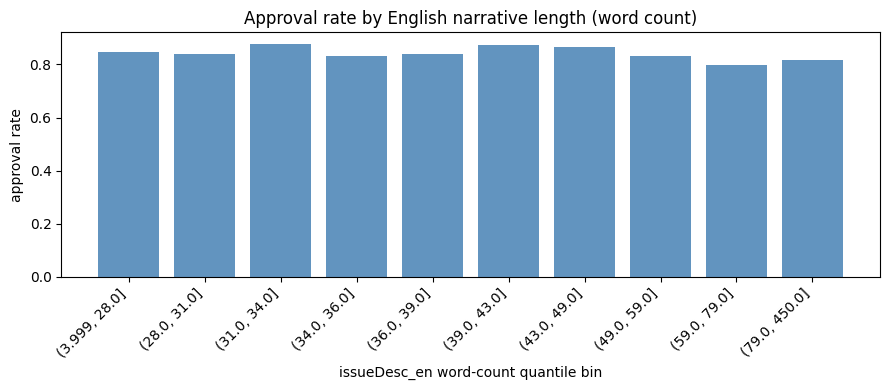

Spearman rho(word_count, approved) = -0.0332, p = 0.07487


In [75]:
import matplotlib.pyplot as plt
from scipy import stats

# Interpretation (expand in the markdown cell above):
# - Word count = len(str.split()) on English text: a simple length/detail proxy, not tokenizer tokens.
# - qcut bins ~equal row mass; bar height is empirical P(approved | bin).
# - Spearman rho measures monotone association with approval; correlation is not causation.

def _issue_en_word_counts(s: pd.Series) -> pd.Series:
    t = s.astype(str).str.strip()
    t = t.mask(t.str.lower().isin(["", "nan", "none"]))
    return t.str.split().str.len()


df["_wc_issue_en"] = _issue_en_word_counts(df["issueDesc_en"])
_mask = df["_wc_issue_en"].notna() & (df["_wc_issue_en"] > 0)
_plot_df = df.loc[_mask].copy()

q = min(10, int(_plot_df["_wc_issue_en"].nunique()))
_plot_df["_wc_bin"] = pd.qcut(
    _plot_df["_wc_issue_en"], q=q, duplicates="drop"
)

_tbl = (
    _plot_df.groupby("_wc_bin", observed=True)["approved"]
    .agg(n="size", approval_rate="mean")
    .reset_index()
)
display(_tbl)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(_tbl)), _tbl["approval_rate"].values, color="steelblue", alpha=0.85)
ax.set_xticks(range(len(_tbl)))
ax.set_xticklabels([str(b) for b in _tbl["_wc_bin"]], rotation=45, ha="right")
ax.set_ylabel("approval rate")
ax.set_xlabel("issueDesc_en word-count quantile bin")
ax.set_title("Approval rate by English narrative length (word count)")
plt.tight_layout()
plt.show()

rho, pval = stats.spearmanr(_plot_df["_wc_issue_en"], _plot_df["approved"])
print(f"Spearman rho(word_count, approved) = {rho:.4f}, p = {pval:.4g}")


## Missing-value analysis

We check which columns are sparse, whether missingness is random or structural, and whether gaps can be filled by looking up values from other rows with the same device profile (e.g., same `model` + `make`).


In [76]:
# Overall missingness rates
miss_rates = df.isna().mean().sort_values(ascending=False)
miss_rates = miss_rates[miss_rates > 0]
print(f"Columns with any missing values: {len(miss_rates)} / {df.shape[1]}")
print()
miss_rates.to_frame("miss_rate").assign(
    miss_n=lambda t: (t["miss_rate"] * len(df)).astype(int),
    miss_pct=lambda t: (t["miss_rate"] * 100).round(1),
)


Columns with any missing values: 18 / 46



,miss_rate,miss_n,miss_pct
other,0.776042,2235,77.6
frontOrBackCamera,0.651736,1877,65.2
smashed,0.651736,1877,65.2
deviceType,0.484028,1394,48.4
charging,0.235069,677,23.5
connection,0.235069,677,23.5
retailerName,0.125347,361,12.5
frontCamera,0.077083,222,7.7
audio,0.077083,222,7.7
backCamera,0.077083,222,7.7


## Check -- is missingness structural (same rows missing together)?

If groups of columns go missing on exactly the same rows, it suggests a structural cause (e.g., a form version that didn't collect those fields).


In [77]:
# Check if columns go missing together (structural patterns)
_sparse_cols = miss_rates[miss_rates > 0.05].index.tolist()
print(f"Columns with >5% missing: {_sparse_cols}")
print()

# Missingness correlation: do the same rows have NaNs?
_miss_matrix = df[_sparse_cols].isna().astype(int)
_miss_corr = _miss_matrix.corr()

# Show pairs with high co-missingness (corr > 0.8)
print("High co-missingness pairs (corr > 0.8):")
_pairs = []
for i, col_a in enumerate(_sparse_cols):
    for col_b in _sparse_cols[i+1:]:
        r = _miss_corr.loc[col_a, col_b]
        if abs(r) > 0.8:
            _pairs.append((col_a, col_b, round(r, 3)))
            print(f"  {col_a:25s} <-> {col_b:25s}  corr={r:.3f}")
if not _pairs:
    print("  (none)")
print()

# Group rows by missingness pattern
_patterns = _miss_matrix.apply(lambda r: tuple(r), axis=1)
_pat_counts = _patterns.value_counts().head(10)
print(f"Top 10 missingness patterns (across {len(_sparse_cols)} sparse columns):")
for pat, cnt in _pat_counts.items():
    cols_missing = [c for c, v in zip(_sparse_cols, pat) if v == 1]
    print(f"  n={cnt:5d}  missing: {cols_missing if cols_missing else '(none)'}")

# Interpretation:
# If certain columns always go missing together, they likely come from the same
# data source or form section. This is NOT random missingness.


Columns with >5% missing: ['other', 'frontOrBackCamera', 'smashed', 'deviceType', 'charging', 'connection', 'retailerName', 'frontCamera', 'audio', 'backCamera', 'mic', 'buttons', 'turnOnOff', 'touchScreen']

High co-missingness pairs (corr > 0.8):
  frontOrBackCamera         <-> smashed                    corr=1.000
  charging                  <-> connection                 corr=1.000
  frontCamera               <-> audio                      corr=1.000
  frontCamera               <-> backCamera                 corr=1.000
  frontCamera               <-> mic                        corr=1.000
  frontCamera               <-> buttons                    corr=0.998
  frontCamera               <-> turnOnOff                  corr=0.955
  frontCamera               <-> touchScreen                corr=0.953
  audio                     <-> backCamera                 corr=1.000
  audio                     <-> mic                        corr=1.000
  audio                     <-> buttons            

## Check -- can missing values be filled via lookup?

For categorical columns like `deviceType` and `retailerName`, we check if other rows with the **same `model` + `make`** always have the same value. If so, we can impute by lookup.

For symptom flags, missing likely means "not reported" rather than "unknown value" -- filling with 0 vs leaving as NaN has different modeling implications.


In [78]:
# Can we fill missing values by looking up from same device profile?
# Group key: (model, make) -- the most granular device identifier we have

_lookup_cols = ["deviceType", "retailerName"]  # categorical columns worth imputing
_group_key = ["model", "make"]

print("=== Lookup imputation feasibility ===")
print(f"Group key: {_group_key}")
print()

for col in _lookup_cols:
    _n_miss = df[col].isna().sum()
    if _n_miss == 0:
        print(f"{col}: no missing values, skip")
        continue

    # For rows where col is missing, find the (model, make) group
    _miss_mask = df[col].isna()
    _miss_groups = df.loc[_miss_mask, _group_key].drop_duplicates()

    # For each missing group, check if non-missing rows in the same group have a unique value
    _fillable = 0
    _conflicting = 0
    _no_donor = 0

    for _, row in _miss_groups.iterrows():
        _same_group = df[
            (df[_group_key[0]] == row[_group_key[0]])
            & (df[_group_key[1]] == row[_group_key[1]])
        ]
        _non_miss = _same_group[col].dropna()
        if len(_non_miss) == 0:
            _no_donor += 1
        elif _non_miss.nunique() == 1:
            _fillable += 1
        else:
            _conflicting += 1

    _total_groups = len(_miss_groups)
    print(f"{col} ({_n_miss} missing rows, {_total_groups} distinct device groups):")
    print(f"  Fillable (1 unique donor value):  {_fillable} groups")
    print(f"  Conflicting (multiple values):    {_conflicting} groups")
    print(f"  No donor (all NaN in group):      {_no_donor} groups")
    _fill_pct = (_fillable / _total_groups * 100) if _total_groups > 0 else 0
    print(f"  => {_fill_pct:.0f}% of device groups can be cleanly imputed")
    print()

# Interpretation:
# If a high % of groups are "fillable", lookup imputation is viable.
# "Conflicting" groups mean the same device has multiple values for that column
# (data quality issue or the field is not device-level).
# "No donor" groups mean no row in that group has a non-null value.


=== Lookup imputation feasibility ===
Group key: ['model', 'make']



deviceType (1394 missing rows, 187 distinct device groups):
  Fillable (1 unique donor value):  69 groups
  Conflicting (multiple values):    1 groups
  No donor (all NaN in group):      117 groups
  => 37% of device groups can be cleanly imputed

retailerName (361 missing rows, 105 distinct device groups):
  Fillable (1 unique donor value):  23 groups
  Conflicting (multiple values):    66 groups
  No donor (all NaN in group):      16 groups
  => 22% of device groups can be cleanly imputed



## Check -- symptom flag missingness vs `approved`

Missing symptom flags may not be "unknown" -- they could mean "not assessed" or come from a form version without that field. We check if rows with missing flags have different approval rates than rows with flags present.


In [79]:
# Symptom flag missingness: is it associated with approval?
_SYMPTOMS = (
    "turnOnOff touchScreen smashed frontCamera backCamera frontOrBackCamera "
    "audio mic buttons connection charging"
).split()

_sym_miss_rows = []
for c in _SYMPTOMS:
    if c not in df.columns:
        continue
    v = pd.to_numeric(df[c], errors="coerce")
    _present = v.notna()
    _absent = v.isna()
    if _absent.sum() == 0 or _present.sum() == 0:
        continue
    _sym_miss_rows.append({
        "flag": c,
        "n_present": int(_present.sum()),
        "n_missing": int(_absent.sum()),
        "miss_pct": round(_absent.mean() * 100, 1),
        "approve_when_present": round(df.loc[_present, "approved"].mean(), 4),
        "approve_when_missing": round(df.loc[_absent, "approved"].mean(), 4),
        "delta": round(df.loc[_present, "approved"].mean() - df.loc[_absent, "approved"].mean(), 4),
    })

_sym_miss_df = pd.DataFrame(_sym_miss_rows)
_sym_miss_df

# Interpretation:
# If approve_when_missing differs substantially from approve_when_present,
# missingness is NOT random w.r.t. outcome -- filling with 0 would be misleading.
# If delta ~ 0, missingness is likely independent of outcome and can be safely
# handled (fill with 0, impute, or drop).


,flag,n_present,n_missing,miss_pct,approve_when_present,approve_when_missing,delta
0,turnOnOff,2676,204,7.1,0.8445,0.8186,0.0259
1,touchScreen,2677,203,7.0,0.8446,0.8177,0.0269
2,smashed,1003,1877,65.2,0.8345,0.8471,-0.0126
3,frontCamera,2658,222,7.7,0.8446,0.8198,0.0248
4,backCamera,2658,222,7.7,0.8446,0.8198,0.0248
5,frontOrBackCamera,1003,1877,65.2,0.8345,0.8471,-0.0126
6,audio,2658,222,7.7,0.8446,0.8198,0.0248
7,mic,2658,222,7.7,0.8446,0.8198,0.0248
8,buttons,2659,221,7.7,0.8447,0.8190,0.0257
9,connection,2203,677,23.5,0.8389,0.8552,-0.0164


## Persona Assignment (GenAI)

Naive keyword matching is too error-prone for assigning personas (e.g., "car" matches "care", "run" matches "battery ran out"). Instead, we use the LLM to understand the nuance of the incident description and assign the correct persona, with a regex-based fallback.

In [80]:
import os
import json
import re
from tqdm.notebook import tqdm
from app.genai.gemini import generate_content
from app.ml.persona_labels import normalize_persona_label

_persona_cache_path = PROJECT_ROOT / "notebooks" / "persona_cache.json"

def _load_persona_cache():
    if _persona_cache_path.exists():
        try:
            return json.loads(_persona_cache_path.read_text(encoding="utf-8"))
        except:
            return {}
    return {}

def _save_persona_cache(cache):
    _persona_cache_path.write_text(json.dumps(cache, indent=2, ensure_ascii=False), encoding="utf-8")

_persona_cache = _load_persona_cache()


# Only classify unique descriptions that aren't cached
_unique_descs = df["issueDesc_en"].dropna().unique().tolist()
_descs_to_classify = [d for d in _unique_descs if d and d not in _persona_cache]

_api = (os.getenv("GEMINI_API_KEY") or "").strip()
_model = (os.getenv("GEMINI_MODEL") or "gemini-2.5-flash-lite").strip()

if _descs_to_classify and _api:
    _system_persona = (
        "Categorize each insurance claim description into EXACTLY ONE of the following personas:\n"
        "- The Victim (Theft/Loss)\n"
        "- The Unlucky Spiller (Liquid Damage)\n"
        "- The Active/Sporty (Action Damage)\n"
        "- The Family/Pet Owner (Chaos Damage)\n"
        "- The Commuter (Transit Damage)\n"
        "- The Professional (Workplace Accident)\n"
        "- The Clumsy Dropper (Standard Accidental)\n\n"
        "Return ONLY a JSON object mapping the index number to the Persona string."
    )
    
    _BATCH_SIZE = 150
    _batch_indices = list(range(0, len(_descs_to_classify), _BATCH_SIZE))
    _pbar = tqdm(_batch_indices, desc="Assigning Personas")
    
    try:
        for _off in _pbar:
            _chunk = _descs_to_classify[_off : _off + _BATCH_SIZE]
            _numbered = "\n".join(f"{i}|{txt[:1000]}" for i, txt in enumerate(_chunk))
            _user = f"Classify these claims (index before |):\n\n{_numbered}"
            
            _raw = generate_content(
                api_key=_api, model=_model, system_text=_system_persona, user_text=_user,
                temperature=0.0, max_output_tokens=8192, timeout_s=300.0,
                max_retries=10, retry_base_s=4.0
            )
            
            # Robust parsing
            raw_st = _raw.strip()
            fenced = re.findall(r"```(?:json)?\s*([\s\S]*?)\s*```", raw_st)
            blob = fenced[0].strip() if fenced else raw_st
            try:
                obj = json.loads(blob)
            except:
                import ast
                try:
                    obj = ast.literal_eval(blob)
                except:
                    cleaned_blob = re.sub(r'\\(?![\"\\\\/bfnrtu])', r'\\\\', blob)
                    try:
                        obj = json.loads(cleaned_blob)
                    except:
                        obj = {}
                        
            if isinstance(obj, dict):
                for key, val in obj.items():
                    try:
                        idx = int(key)
                        if 0 <= idx < len(_chunk):
                            _persona_cache[_chunk[idx]] = normalize_persona_label(str(val).strip())
                    except:
                        pass
            
            _pbar.set_postfix({"cached": len(_persona_cache)})
            _save_persona_cache(_persona_cache)
    except KeyboardInterrupt:
        print("\n[Persona] Interrupted. Saving progress...")
    finally:
        _save_persona_cache(_persona_cache)
        print(f"Persona cache saved to {_persona_cache_path}.")

def assign_persona_llm(row):
    txt = str(row.get("issueDesc_en") or row.get("issue_desc_en") or row.get("issueDesc", ""))
    if txt and txt in _persona_cache:
        return _persona_cache[txt]
    
    # Fallback to rule-based if LLM failed or API key missing
    text_lower = txt.lower()
    ctype = str(row.get("claimType", "")).lower()
    
    if "theft" in ctype or re.search(r"\b(stole|stolen|robbed|thief|pickpocket)\b", text_lower):
        return "The Victim (Theft/Loss)"
    elif "liquid" in ctype or re.search(r"\b(water|spilled|liquid|toilet|rain|pool|sink|wet)\b", text_lower):
        return "The Unlucky Spiller (Liquid Damage)"
    elif re.search(r"\b(gym|run|running|bike|cycle|cycling|workout|tennis|padel|sport)\b", text_lower):
        return "The Active/Sporty (Action Damage)"
    elif re.search(r"\b(kid|child|baby|son|daughter|toddler|dog|cat|pet)\b", text_lower):
        return "The Family/Pet Owner (Chaos Damage)"
    elif re.search(r"\b(car|driving|truck|bus|train|commute|subway|tram)\b", text_lower):
        return "The Commuter (Transit Damage)"
    elif re.search(r"\b(work|office|desk|coworker|colleague|colleagues)\b", text_lower):
        return "The Professional (Workplace Accident)"
    else:
        return "The Clumsy Dropper (Standard Accidental)"

df["persona"] = df.apply(assign_persona_llm, axis=1)
df["persona"] = df["persona"].map(normalize_persona_label)
print("\n=== Claimant Personas (normalized) ===")
print(df["persona"].value_counts())



=== Claimant Personas ===
persona
The Clumsy Dropper                          1629
The Clumsy Dropper (Standard Accidental)     275
The Commuter                                 257
The Professional                             149
The Family/Pet Owner                         131
The Active/Sporty                            111
The Victim                                    77
The Unlucky Spiller                           68
The Professional (Workplace Accident)         46
The Family/Pet Owner (Chaos Damage)           41
The Active/Sporty (Action Damage)             36
The Commuter (Transit Damage)                 27
The Victim (Theft/Loss)                       26
The Unlucky Spiller (Liquid Damage)            7
Name: count, dtype: int64


## Export Final Dataset

Save the dataframe (with `issueDesc_en` translations and `persona` assignments) to a new CSV file for downstream ML and GenAI consumption.

In [81]:
out_csv = PROJECT_ROOT / "data" / "claim_use_case_dataset_enriched.csv"
out_csv.parent.mkdir(exist_ok=True)
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"Exported {len(df)} rows to {out_csv}")


Exported 2880 rows to C:\coding\boltech\data\claim_use_case_dataset_enriched.csv
